# 03. Computer Vision — Solutions

### Overview & Objectives
* **Overfitting Diagnostics & Mitigation:** Identifying generalization gaps between train and test splits; applying regularization, batching, and architectural tuning to prevent memorization.
* **Data Ingestion & Batching:** Loading the FashionMNIST benchmark dataset, converting raw image samples into optimized iterable `DataLoader` instances with configurable batch sizes.
* **CNN Architecture & Spatial Hyperparameters:** Implementing 2D convolutional networks while tuning structural parameters (`kernel_size`, `stride`, `padding`, `in_channels`, `out_channels`).
* **Hardware Acceleration & Training Loops:** Executing multi-epoch training and validation loops across CPU and CUDA (`torch.device`) targets.
* **Inference & Diagnostic Evaluation:** Generating class-level predictions under `torch.inference_mode()` and visualizing classification performance using a multi-class Confusion Matrix.

--------------
--------------

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Sat May 30 14:36:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.10.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

1. Self Driving Cars
2. Healthcare Imaging
3. Drone Imaging
4. Satellite/Geological Imaging
5. Security(Border Security/Home Security)

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

Overfitting is the phenomenon when our model memorizes the parameters instead of learning , peform really well on training data but perform really poor in testing data.
These patterns learned dont generalize well on unseen data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Regularization: L1/L2 regularization which adds penalty to the big weights(L1-absolute, L2-squared).
2. Change model: Pick a simpler model with less layers / lesser parameters.
3. Data Augmentation: Change shape, size, rotate data.(artificially inducing noise)
4. Reduce noise/data cleanup - remove the noise/clean up the dataset.
5. Dropout - Dropout neurons while training like ResNet so model doesnot overdepend on a single neuron.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

In [3]:
import torchvision
from torchvision import datasets
from torchvision import transforms

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
# Get the MNIST
train_data = datasets.MNIST(
    root = ".", # Save data in current folder(root folder) MNIST instead of subfolder like data
    train = True,
    download = True,
    transform = transforms.ToTensor()   
    # No need of target transform here as we'rent transforming target tensors into labels(labels are numbers itself from 0 to 9)
) 

test_data = datasets.MNIST(
    root = ".",
    train = False,
    download = True,
    transform = transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.80MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [5]:
train_data, test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: .
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: .
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [6]:
image,label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 5)

In [7]:
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [8]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [9]:
classes = train_data.classes
classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

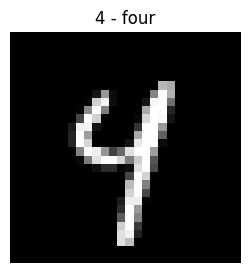

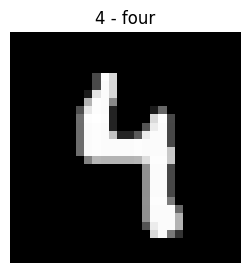

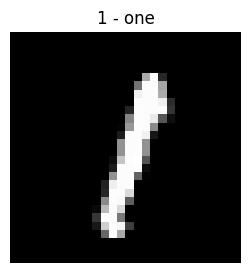

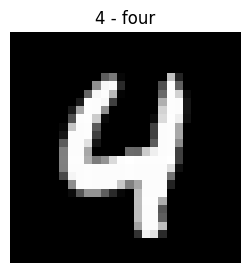

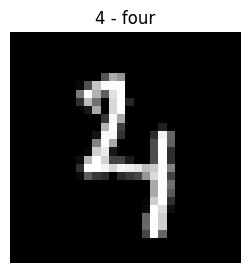

In [10]:
# Visualize 5 samples
import matplotlib.pyplot as plt

for i in range(5):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig = plt.figure(figsize=(3,3))
    plt.imshow(img.squeeze(), cmap = "gray") #grayscale images(so image shape [1,28,28])
    plt.title(classes[label])
    plt.axis(False);

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)

train_dataloader, test_dataloader, len(train_dataloader), len(test_dataloader)

(<torch.utils.data.dataloader.DataLoader at 0x7a8871665130>,
 1875,
 313)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [16]:
from torch import nn

torch.manual_seed(42)
torch.cuda.manual_seed(42)

class MNIST_Model(nn.Module):
    """
    Model for predicting MNIST dataset with TinyVGG Architecture"""
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Conv block 1
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units*7*7,
                      out_features = output_shape) #28x28 image and 2 maxpool layer
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [17]:
device

'cuda'

In [18]:
model = MNIST_Model(input_shape = 1,
                    hidden_units = 10,
                    output_shape = len(classes)).to(device)
model

MNIST_Model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [21]:
# Try out a dummy forward pass to test how our model is performing 
dummy_x = torch.rand(size=(1,28,28)).unsqueeze(dim=0).to(device)
res = model(dummy_x)
res, res.shape

(tensor([[ 0.0327, -0.0715,  0.0613, -0.0434, -0.0058,  0.0239,  0.0017, -0.0127,
           0.0226,  0.0067]], device='cuda:0', grad_fn=<AddmmBackward0>),
 torch.Size([1, 10]))

In [24]:
# Flatten a dummy_tensor
dummy_x2 = torch.rand(size=(1,10,7,7)).to(device) #output size from model
flatten_layer = nn.Flatten()
dummy_x2.shape, flatten_layer(res), flatten_layer(dummy_x2).shape

(torch.Size([1, 10, 7, 7]),
 tensor([[ 0.0327, -0.0715,  0.0613, -0.0434, -0.0058,  0.0239,  0.0017, -0.0127,
           0.0226,  0.0067]], device='cuda:0', grad_fn=<AddmmBackward0>),
 torch.Size([1, 490]))

In [25]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
    print("helper_funcitons.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:  #open file with write binary permissions
        f.write(request.content)
    print("Downloaded")

Downloaded


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [29]:
# Train on CPU
from tqdm.auto import tqdm
from helper_functions import print_train_time, accuracy_fn
from timeit import default_timer as timer

train_time_start_on_cpu = timer()
# Train on CPU
model_cpu = MNIST_Model(input_shape = 1,
                        hidden_units = 10,
                        output_shape = 10).to("cpu")

# Create a loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_cpu.parameters(),
                            lr = 0.1)

## Training Loop
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---")
    train_loss, train_acc = 0, 0
    for batch, (X,y) in enumerate(train_dataloader):
        model_cpu.train()

        # Put data on CPU
        X, y = X.to("cpu"), y.to("cpu")

        #1. Forward Pass
        y_pred = model_cpu(X)
        
        #2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        
        train_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim=1))
        
        #3. Optimizer zero grad
        optimizer.zero_grad()
        
        #4. Loss Backward(Backpropagation)
        loss.backward()
        
        #5. Optimizer step(gradient descent)
        optimizer.step()
        
    # train_loss and train_acc per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    ## Testing Loop
    test_loss, test_acc = 0, 0
    # Put model on eval mode
    model_cpu.eval()
    with torch.inference_mode():
        for (X_test, y_test) in test_dataloader:
            # Put data on cpu
            X_test, y_test = X_test.to("cpu"), y_test.to("cpu")

            #1. Forward Pass
            test_pred = model_cpu(X_test)

            #2. Calculate the loss
            testLoss = loss_fn(test_pred, y_test)
            test_loss += testLoss

            test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim=1))

        # test_loss and test_acc per batch
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    
    # Print out what's happening
    print(f"Train loss: {train_loss:.4f}, Training accuracy: {train_acc:.4f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n")

train_time_end_on_cpu = timer()

total_train_time_on_cpu = print_train_time(start = train_time_start_on_cpu,
                                           end = train_time_end_on_cpu,
                                           device = "cpu")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
---
Train loss: 0.3544, Training accuracy: 87.9917% | Test loss: 0.0864, Test acc: 97.0647

Epoch 1
---
Train loss: 0.0703, Training accuracy: 97.9200% | Test loss: 0.0577, Test acc: 98.0331

Epoch 2
---
Train loss: 0.0530, Training accuracy: 98.3867% | Test loss: 0.0475, Test acc: 98.3926

Epoch 3
---
Train loss: 0.0468, Training accuracy: 98.5050% | Test loss: 0.0405, Test acc: 98.5523

Epoch 4
---
Train loss: 0.0403, Training accuracy: 98.7000% | Test loss: 0.0399, Test acc: 98.6921


Train time on cpu: 130.131 seconds


In [30]:
device

'cuda'

In [32]:
# Train on CPU
from tqdm.auto import tqdm
from helper_functions import print_train_time, accuracy_fn
from timeit import default_timer as timer

train_time_start_on_gpu = timer()
# Train on CPU
model_gpu = MNIST_Model(input_shape = 1,
                        hidden_units = 10,
                        output_shape = 10).to(device)

# Create a loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_gpu.parameters(),
                            lr = 0.1)

## Training Loop
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---")
    train_loss, train_acc = 0, 0
    for batch, (X,y) in enumerate(train_dataloader):
        model_gpu.train()

        # Put data on GPU
        X, y = X.to(device), y.to(device)

        #1. Forward Pass
        y_pred = model_gpu(X)
        
        #2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        
        train_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim=1))
        
        #3. Optimizer zero grad
        optimizer.zero_grad()
        
        #4. Loss Backward(Backpropagation)
        loss.backward()
        
        #5. Optimizer step(gradient descent)
        optimizer.step()
        
    # train_loss and train_acc per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    ## Testing Loop
    test_loss, test_acc = 0, 0
    # Put model on eval mode
    model_gpu.eval()
    with torch.inference_mode():
        for (X_test, y_test) in test_dataloader:
            # Put data on gpu
            X_test, y_test = X_test.to(device), y_test.to(device)

            #1. Forward Pass
            test_pred = model_gpu(X_test)

            #2. Calculate the loss
            testLoss = loss_fn(test_pred, y_test)
            test_loss += testLoss

            test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim=1))

        # test_loss and test_acc per batch
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    
    # Print out what's happening
    print(f"Train loss: {train_loss:.4f}, Training accuracy: {train_acc:.4f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n")

train_time_end_on_gpu = timer()

total_train_time_on_gpu = print_train_time(start = train_time_start_on_gpu,
                                           end = train_time_end_on_gpu,
                                           device = device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
---
Train loss: 0.2919, Training accuracy: 90.0050% | Test loss: 0.0553, Test acc: 98.1230

Epoch 1
---
Train loss: 0.0690, Training accuracy: 97.8567% | Test loss: 0.0533, Test acc: 98.2927

Epoch 2
---
Train loss: 0.0552, Training accuracy: 98.2683% | Test loss: 0.0440, Test acc: 98.5224

Epoch 3
---
Train loss: 0.0479, Training accuracy: 98.4600% | Test loss: 0.0508, Test acc: 98.4724

Epoch 4
---
Train loss: 0.0422, Training accuracy: 98.6467% | Test loss: 0.0526, Test acc: 98.2927


Train time on cuda: 53.696 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

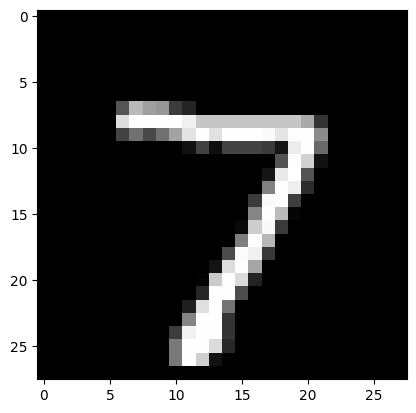

In [34]:
plt.imshow(test_data[0][0].squeeze(), cmap = "gray");

In [35]:
# Prediction using model_gpu
y_logits = model_gpu(test_data[0][0].unsqueeze(dim=0).to(device))
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_label = torch.argmax(y_pred_probs, dim=1)
y_pred_label

tensor([7], device='cuda:0')

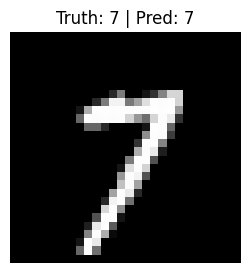

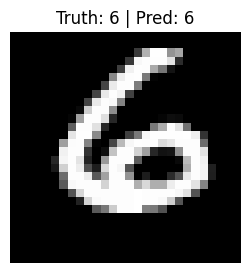

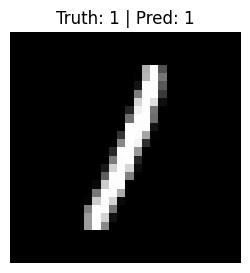

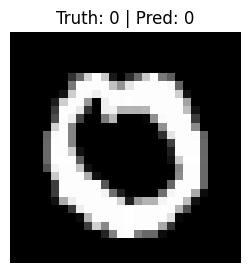

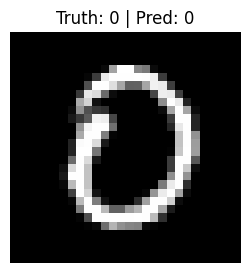

In [36]:
# Plot 5 predictions
for i in range(5):
    random_idx = torch.randint(0, len(test_data), size=[1]).item()
    img, label = test_data[random_idx]

    # Make predictions on images
    model_pred_logits = model_gpu(img.unsqueeze(dim=0).to(device))
    model_pred_probs = torch.softmax(model_pred_logits, dim=1)
    model_pred_label = torch.argmax(model_pred_probs, dim=1)

    # Plot the image and prediction
    fig = plt.figure(figsize=(3,3))
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(f"Truth: {label} | Pred: {model_pred_label.cpu().item()}")
    plt.axis(False);

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [37]:
import torchmetrics, mlxtend

In [39]:
# Make predictions across all test data
model_gpu.eval()
y_preds = []
with torch.inference_mode():
    for (X_test, y_test) in test_dataloader:
        # Put data on device
        X_test, y_test = X_test.to(device), y_test.to(device)

        #Forward Pass
        y_pred_logits = model_gpu(X_test)
        y_pred_labels = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)

        # Append y_pred_labels to preds list
        y_preds.append(y_pred_labels)
        
    y_preds = torch.cat(y_preds).cpu()
len(y_preds)

10000

In [40]:
test_data.targets[:10], y_preds[:10]

(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]))

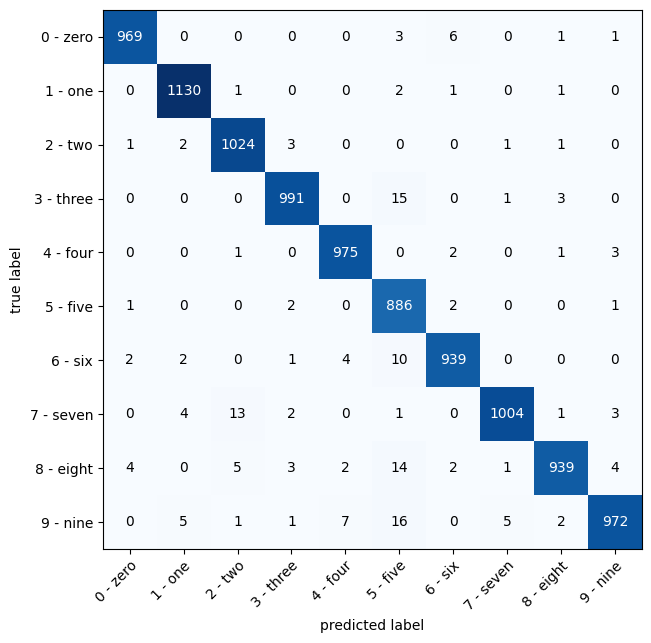

In [41]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup Confusion Matrix
confmat = ConfusionMatrix(task="multiclass", num_classes=len(classes))
confmat_tensor = confmat(preds = y_preds,
                         target = test_data.targets)

# Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = classes,
    figsize=(10,7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [45]:
random_tensor = torch.rand(size=(1,3,64,64))
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 64,
                       kernel_size = 3,
                       stride = 1,
                       padding =1)

print(f"Random tensor original shape: {random_tensor.shape}")
random_tensor_through_conv_layer = conv_layer(random_tensor)
print(f"Random tensor through conv layer shape: {random_tensor_through_conv_layer.shape}")

Random tensor original shape: torch.Size([1, 3, 64, 64])
Random tensor through conv layer shape: torch.Size([1, 64, 64, 64])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [46]:
# Download FashionMNIST train & test
from torchvision import datasets
from torchvision import transforms

fashion_mnist_train = datasets.FashionMNIST(root="data",
                                            download=True,
                                            train=True,
                                            transform=transforms.ToTensor())

fashion_mnist_test = datasets.FashionMNIST(root="data",
                                           train=False,
                                           download=True,
                                           transform=transforms.ToTensor())

len(fashion_mnist_train), len(fashion_mnist_test)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 301kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.68MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]


(60000, 10000)

In [47]:
# Get the class names of the Fashion MNIST dataset
fashion_mnist_class_names = fashion_mnist_train.classes
fashion_mnist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [48]:
# Turn FashionMNIST datasets into dataloaders
from torch.utils.data import DataLoader

fashion_mnist_train_dataloader = DataLoader(fashion_mnist_train,
                                            batch_size=32,
                                            shuffle=True)

fashion_mnist_test_dataloader = DataLoader(fashion_mnist_test,
                                           batch_size=32,
                                           shuffle=False)

len(fashion_mnist_train_dataloader), len(fashion_mnist_test_dataloader)

(1875, 313)

In [60]:
# model_2 is the same architecture as MNIST_model
model_2 = MNIST_Model(input_shape=1,
                      hidden_units=10,
                      output_shape=10).to(device)
model_2

MNIST_Model(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [61]:
# Setup loss and optimizer
from torch import nn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [62]:
# Setup metrics
from tqdm.auto import tqdm
from torchmetrics import Accuracy

acc_fn = Accuracy(task = 'multiclass', num_classes=len(fashion_mnist_class_names)).to(device) 

# Setup training/testing loop
epochs = 5
for epoch in tqdm(range(epochs)):
  train_loss, test_loss_total = 0, 0
  train_acc, test_acc = 0, 0 

  ### Training
  model_2.train()
  for batch, (X_train, y_train) in enumerate(fashion_mnist_train_dataloader):
    X_train, y_train = X_train.to(device), y_train.to(device)

    # Forward pass and loss
    y_pred = model_2(X_train)
    loss = loss_fn(y_pred, y_train)
    train_loss += loss
    train_acc += acc_fn(y_pred, y_train)

    # Backprop and gradient descent
    optimizer.zero_grad()
    loss.backward() 
    optimizer.step()

  # Adjust the loss/acc (find the loss/acc per epoch)
  train_loss /= len(fashion_mnist_train_dataloader)
  train_acc /= len(fashion_mnist_train_dataloader)

  ### Testing
  model_2.eval()
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(fashion_mnist_test_dataloader):
      X_test, y_test = X_test.to(device), y_test.to(device)

      # Forward pass and loss
      y_pred_test = model_2(X_test)
      test_loss = loss_fn(y_pred_test, y_test)
      test_loss_total += test_loss

      test_acc += acc_fn(y_pred_test, y_test)
  
    # Adjust the loss/acc (find the loss/acc per epoch)
    test_loss /= len(fashion_mnist_test_dataloader)
    test_acc /= len(fashion_mnist_test_dataloader)
    
  # Print out what's happening
  print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Train acc: {train_acc:.2f} | Test loss: {test_loss:.3f} | Test acc: {test_acc:.2f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.239 | Train acc: 0.56 | Test loss: 0.001 | Test acc: 0.75
Epoch: 1 | Train loss: 0.542 | Train acc: 0.81 | Test loss: 0.001 | Test acc: 0.81
Epoch: 2 | Train loss: 0.455 | Train acc: 0.84 | Test loss: 0.001 | Test acc: 0.84
Epoch: 3 | Train loss: 0.416 | Train acc: 0.85 | Test loss: 0.001 | Test acc: 0.85
Epoch: 4 | Train loss: 0.389 | Train acc: 0.86 | Test loss: 0.001 | Test acc: 0.86


In [63]:
# Make predictions with trained model_2
test_preds = []
model_2.eval()
with torch.inference_mode():
  for X_test, y_test in tqdm(fashion_mnist_test_dataloader):
    y_logits = model_2(X_test.to(device))
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_pred_labels = torch.argmax(y_pred_probs, dim=1)
    test_preds.append(y_pred_labels)
test_preds = torch.cat(test_preds).cpu() # matplotlib likes CPU
test_preds[:10], len(test_preds)    

  0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), 10000)

In [64]:
# Get wrong prediction indexes
import numpy as np
wrong_pred_indexes = np.where(test_preds != fashion_mnist_test.targets)[0]
len(wrong_pred_indexes)

1414

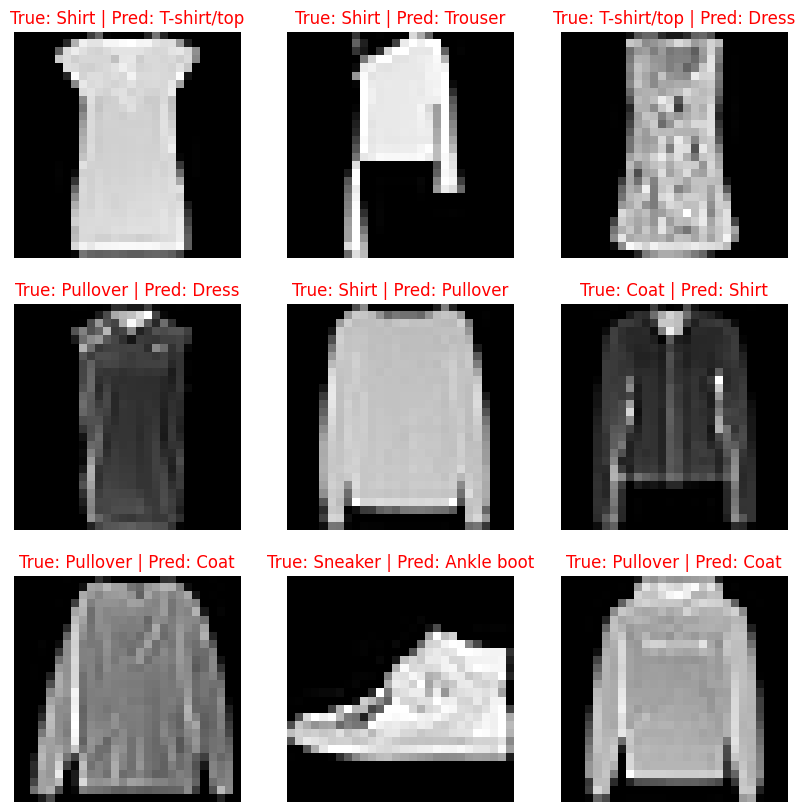

In [65]:
# Select random 9 wrong predictions and plot them
import random
random_selection = random.sample(list(wrong_pred_indexes), k=9)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_selection):
  # Get true and pred labels
  true_label = fashion_mnist_class_names[fashion_mnist_test[idx][1]]
  pred_label = fashion_mnist_class_names[test_preds[idx]]

  # Plot the wrong prediction with its original label
  plt.subplot(3, 3, i+1)
  plt.imshow(fashion_mnist_test[idx][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r")
  plt.axis(False);

In [66]:
# PROBLEM SPACE :: PRE_BUILT DATASETS AND FUNCTIONS
# TorchVision - vision data - torchvision.datasets
# TorchAudio - audio data - torchaudio.datasets
# TorchText - text data - torchtext.datasets
# TorchRec - recommendation system - torchrec.datasets
# Bonus = TorchData*(TorchData contains many different helper functions for loading data)